In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset/CAR DETAILS FROM CAR DEKHO.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (4340, 8)

Column names:
Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [5]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 763


In [6]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3577, 8)


In [7]:
# Descriptive statistics

print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
              year  selling_price      km_driven
count  3577.000000   3.577000e+03    3577.000000
mean   2012.962538   4.739125e+05   69250.545709
std       4.251759   5.093018e+05   47579.940016
min    1992.000000   2.000000e+04       1.000000
25%    2010.000000   2.000000e+05   36000.000000
50%    2013.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


In [8]:
# Check unique values in categorical columns

print("Fuel types:")
print(df["fuel"].value_counts())

print("\nSeller types:")
print(df["seller_type"].value_counts())

print("\nTransmission types:")
print(df["transmission"].value_counts())

print("\nOwner types:")
print(df["owner"].value_counts())

Fuel types:
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

Seller types:
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64

Transmission types:
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

Owner types:
owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64


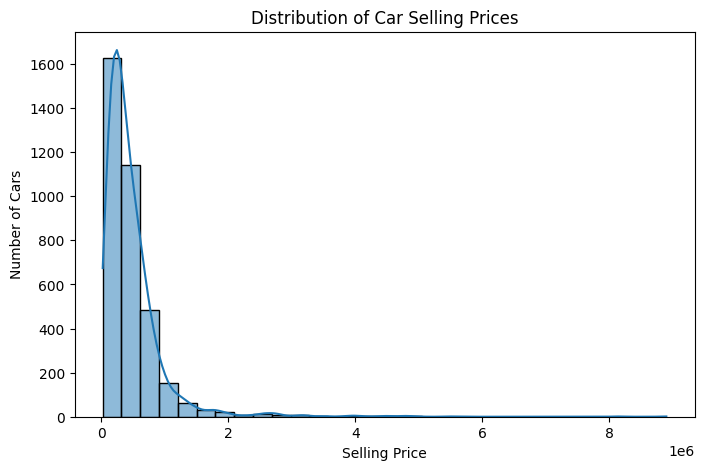

In [9]:
# Distribution of Selling Price

plt.figure(figsize=(8, 5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

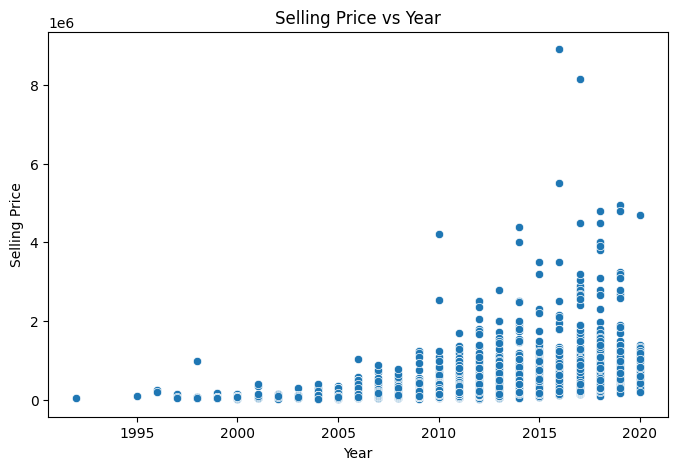

In [10]:
# Selling Price vs Year

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["year"],
    y=df["selling_price"]
)

plt.title("Selling Price vs Year")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.show()

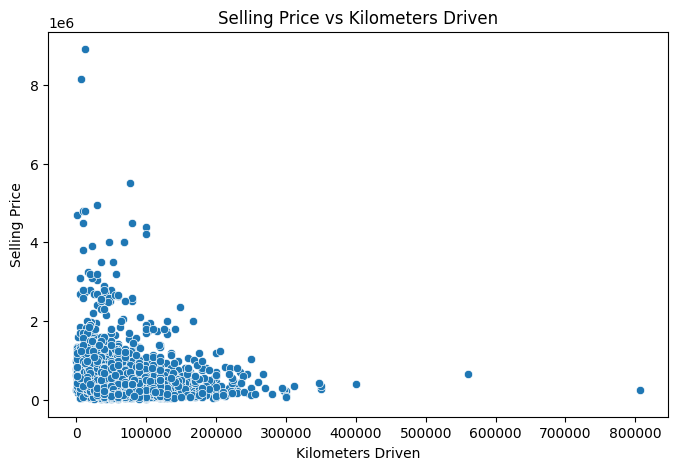

In [11]:
# Selling Price vs Kilometers Driven

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["km_driven"],
    y=df["selling_price"]
)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

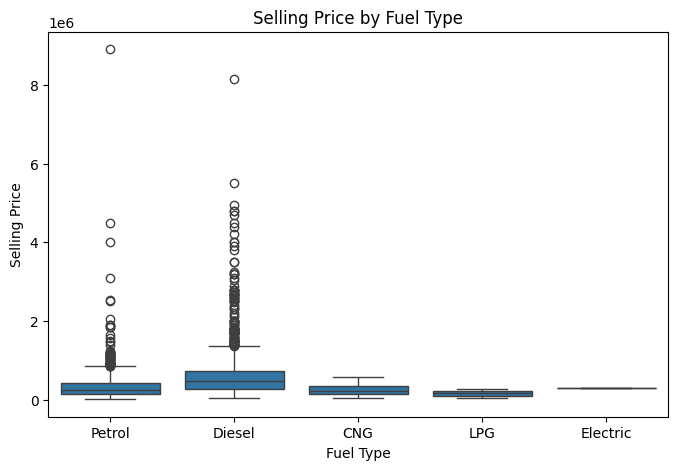

In [12]:
# Selling Price by Fuel Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["fuel"],
    y=df["selling_price"]
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

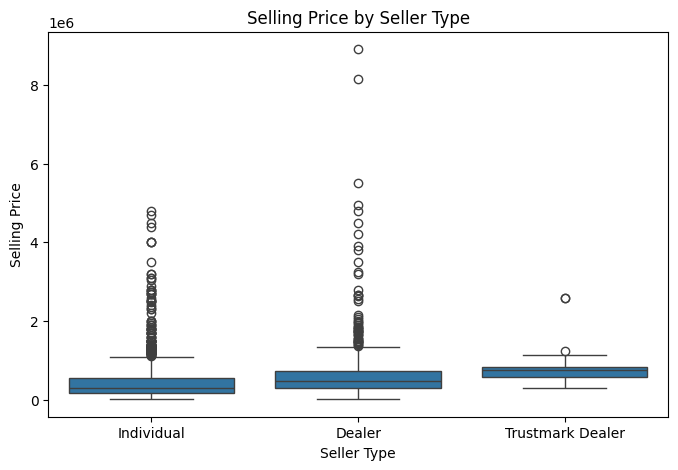

In [13]:
# Selling Price by Seller Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["seller_type"],
    y=df["selling_price"]
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")

plt.show()

In [14]:
# Separate features and target

X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
                       name  year  km_driven    fuel seller_type transmission  \
0             Maruti 800 AC  2007      70000  Petrol  Individual       Manual   
1  Maruti Wagon R LXI Minor  2007      50000  Petrol  Individual       Manual   
2      Hyundai Verna 1.6 SX  2012     100000  Diesel  Individual       Manual   
3    Datsun RediGO T Option  2017      46000  Petrol  Individual       Manual   
4     Honda Amaze VX i-DTEC  2014     141000  Diesel  Individual       Manual   

          owner  
0   First Owner  
1   First Owner  
2   First Owner  
3   First Owner  
4  Second Owner  

Target:
0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64


In [15]:
# Drop car name
X = X.drop("name", axis=1)

print("Features after dropping name:")
print(X.head())

print("\nFeature columns:")
print(X.columns)

Features after dropping name:
   year  km_driven    fuel seller_type transmission         owner
0  2007      70000  Petrol  Individual       Manual   First Owner
1  2007      50000  Petrol  Individual       Manual   First Owner
2  2012     100000  Diesel  Individual       Manual   First Owner
3  2017      46000  Petrol  Individual       Manual   First Owner
4  2014     141000  Diesel  Individual       Manual  Second Owner

Feature columns:
Index(['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


In [16]:
print("Fuel types:")
print(X["fuel"].unique())

print("\nSeller types:")
print(X["seller_type"].unique())

print("\nTransmission types:")
print(X["transmission"].unique())

print("\nOwner types:")
print(X["owner"].unique())

Fuel types:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

Seller types:
['Individual' 'Dealer' 'Trustmark Dealer']

Transmission types:
['Manual' 'Automatic']

Owner types:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [17]:
# One-hot encode categorical columns

X = pd.get_dummies(
    X,
    columns=["fuel", "seller_type", "transmission", "owner"],
    drop_first=True
)

print("Features after encoding:")
print(X.head())

print("\nFeature columns:")
print(X.columns)

Features after encoding:
   year  km_driven  fuel_Diesel  fuel_Electric  fuel_LPG  fuel_Petrol  \
0  2007      70000        False          False     False         True   
1  2007      50000        False          False     False         True   
2  2012     100000         True          False     False        False   
3  2017      46000        False          False     False         True   
4  2014     141000         True          False     False        False   

   seller_type_Individual  seller_type_Trustmark Dealer  transmission_Manual  \
0                    True                         False                 True   
1                    True                         False                 True   
2                    True                         False                 True   
3                    True                         False                 True   
4                    True                         False                 True   

   owner_Fourth & Above Owner  owner_Second Owner  owne

In [18]:
print("Data types after encoding:")
print(X.dtypes)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Data types after encoding:
year                            int64
km_driven                       int64
fuel_Diesel                      bool
fuel_Electric                    bool
fuel_LPG                         bool
fuel_Petrol                      bool
seller_type_Individual           bool
seller_type_Trustmark Dealer     bool
transmission_Manual              bool
owner_Fourth & Above Owner       bool
owner_Second Owner               bool
owner_Test Drive Car             bool
owner_Third Owner                bool
dtype: object

Shape of X: (3577, 13)
Shape of y: (3577,)


In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (2861, 13)
y_train: (2861,)

Testing data:
X_test: (716, 13)
y_test: (716,)


In [20]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [21]:
# Predict selling prices for test data

y_pred_linear = linear_model.predict(X_test)

print("First 10 actual prices:")
print(y_test.head(10).values)

print("\nFirst 10 predicted prices:")
print(y_pred_linear[:10])

First 10 actual prices:
[ 270000  525000  990000 3800000  229999  325000  210000  500000  790000
  360000]

First 10 predicted prices:
[ 488618.55876766  478334.28113052  628427.3407996  1569713.65424204
   33909.8060065   347305.45899452  127300.40492694  668712.8104434
  783671.40301552  297296.92413966]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Performance
--------------------------------
MAE : 213071.17661612606
RMSE: 442304.96876292466
R² Score: 0.3926934834268362


In [23]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [24]:
# Predict selling prices using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("First 10 actual prices:")
print(y_test.head(10).values)

print("\nFirst 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 actual prices:
[ 270000  525000  990000 3800000  229999  325000  210000  500000  790000
  360000]

First 10 Random Forest predictions:
[ 472990.09498263  662966.43666667 1344070.         2326960.
  106370.38095238  350886.9047619   169895.83333333  914060.95238095
  908303.07382215  234599.99      ]


In [25]:
 # Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Performance
-------------------------
MAE : 193601.41007051803
RMSE: 423750.3317683122
R² Score: 0.4425776121400691


In [26]:
# Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
year                            0.276128
km_driven                       0.275607
transmission_Manual             0.255870
fuel_Diesel                     0.080052
fuel_Petrol                     0.037555
seller_type_Individual          0.034694
owner_Second Owner              0.023139
owner_Test Drive Car            0.008627
owner_Third Owner               0.004689
seller_type_Trustmark Dealer    0.002580
owner_Fourth & Above Owner      0.001026
fuel_LPG                        0.000033
fuel_Electric                   0.000000
dtype: float64


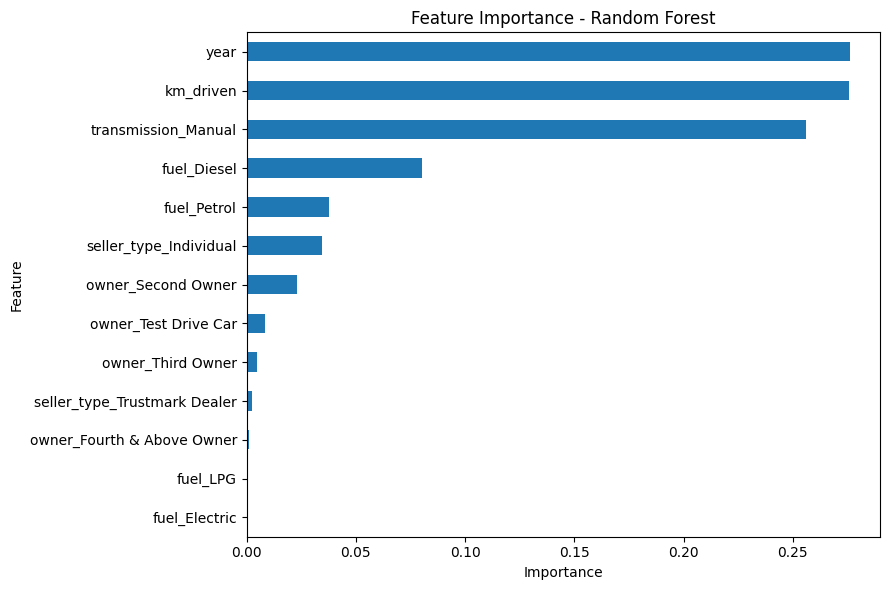

In [27]:
plt.figure(figsize=(9, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

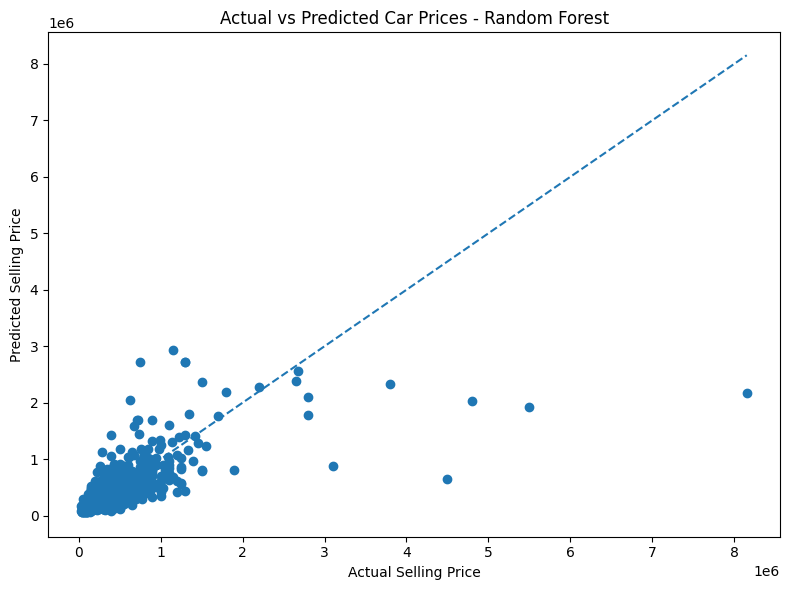

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices - Random Forest")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [29]:
# New car details

new_car = pd.DataFrame({
    "year": [2018],
    "km_driven": [50000],
    "fuel": ["Petrol"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],
    "owner": ["First Owner"]
})

print(new_car)

   year  km_driven    fuel seller_type transmission        owner
0  2018      50000  Petrol  Individual       Manual  First Owner


In [30]:
# Encode the new car using the same encoding method

new_car_encoded = pd.get_dummies(new_car)

# Make sure it has exactly the same columns as X
new_car_encoded = new_car_encoded.reindex(
    columns=X.columns,
    fill_value=False
)

print("Encoded new car:")
print(new_car_encoded)

Encoded new car:
   year  km_driven  fuel_Diesel  fuel_Electric  fuel_LPG  fuel_Petrol  \
0  2018      50000        False          False     False         True   

   seller_type_Individual  seller_type_Trustmark Dealer  transmission_Manual  \
0                    True                         False                 True   

   owner_Fourth & Above Owner  owner_Second Owner  owner_Test Drive Car  \
0                       False               False                 False   

   owner_Third Owner  
0              False  


In [31]:
# Predict the selling price

predicted_price = rf_model.predict(new_car_encoded)

print("Predicted Selling Price: ₹", round(predicted_price[0], 2))

Predicted Selling Price: ₹ 575316.48
